<a href="https://colab.research.google.com/github/Storm00212/8-bit-cpu-using-verilog/blob/main/QUESTION_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy # used scipy cuz numpy does not have duty cycle

# RECTANGULAR PULSE TRAIN FUNCTION

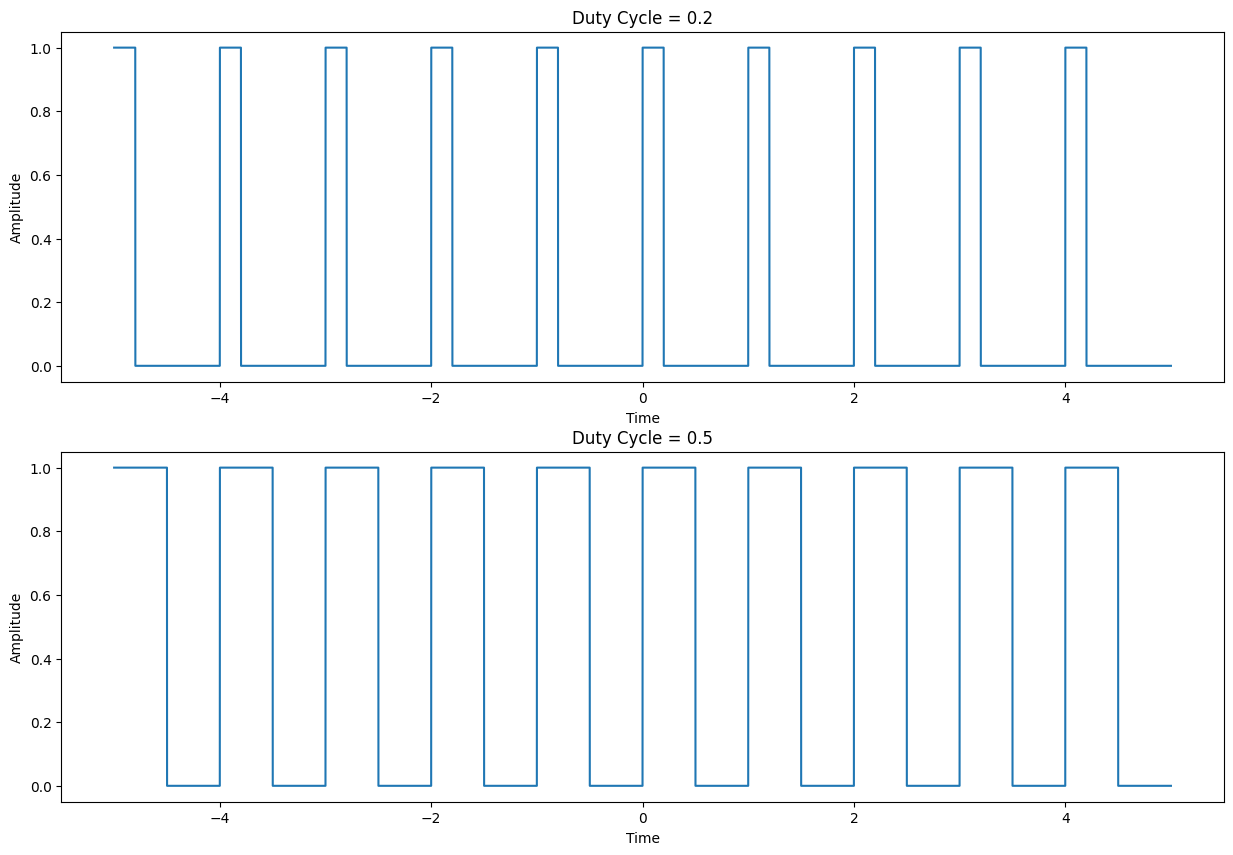

In [10]:
# duty cycle = 0.5
from scipy import signal
t = np.linspace(-5, 5, 1000000, endpoint=False)
duty_cycles = [0.2, 0.5] # what percentage of time does the signal stay on
frequency = 1 #no of cycles/second

# f = (np.sign(np.sin((2*np.pi*t)/4))+1)/2 you can also do it manually

fig, axes = plt.subplots(2, 1, figsize = (15, 10))
for i, duty_cycle in enumerate(duty_cycles):
    f = (scipy.signal.square(2 * np.pi * t, duty=duty_cycles[i])+1)/2 #can divide 2pit by the period u want.
    axes[i].plot(t, f)
    axes[i].set_title(f'Duty Cycle = {duty_cycle}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Amplitude')


# COMPUTING THE FOURIER SERIES COEFFICIENTS

Text(0.5, 1.0, 'Rectangular Pulse Train')

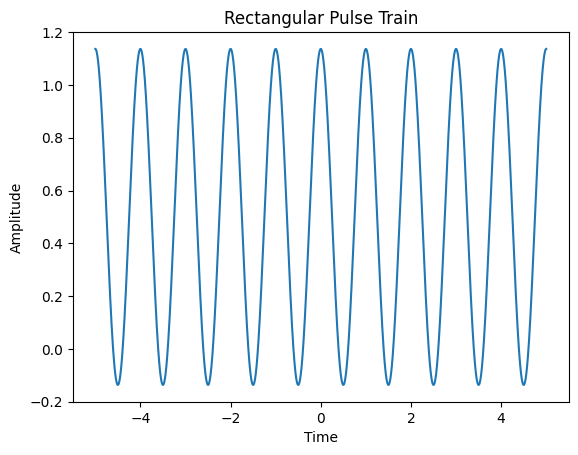

In [11]:
# N = 1 TESTING TO SEE IF IT WORKS FIRST LOL
f= 1/2 + (2/np.pi)*(np.cos(2*np.pi*t))
plt.plot(t, f)
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Rectangular Pulse Train')

/tmp/ipykernel_40830/410337321.py:40: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout() # better plot layout
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


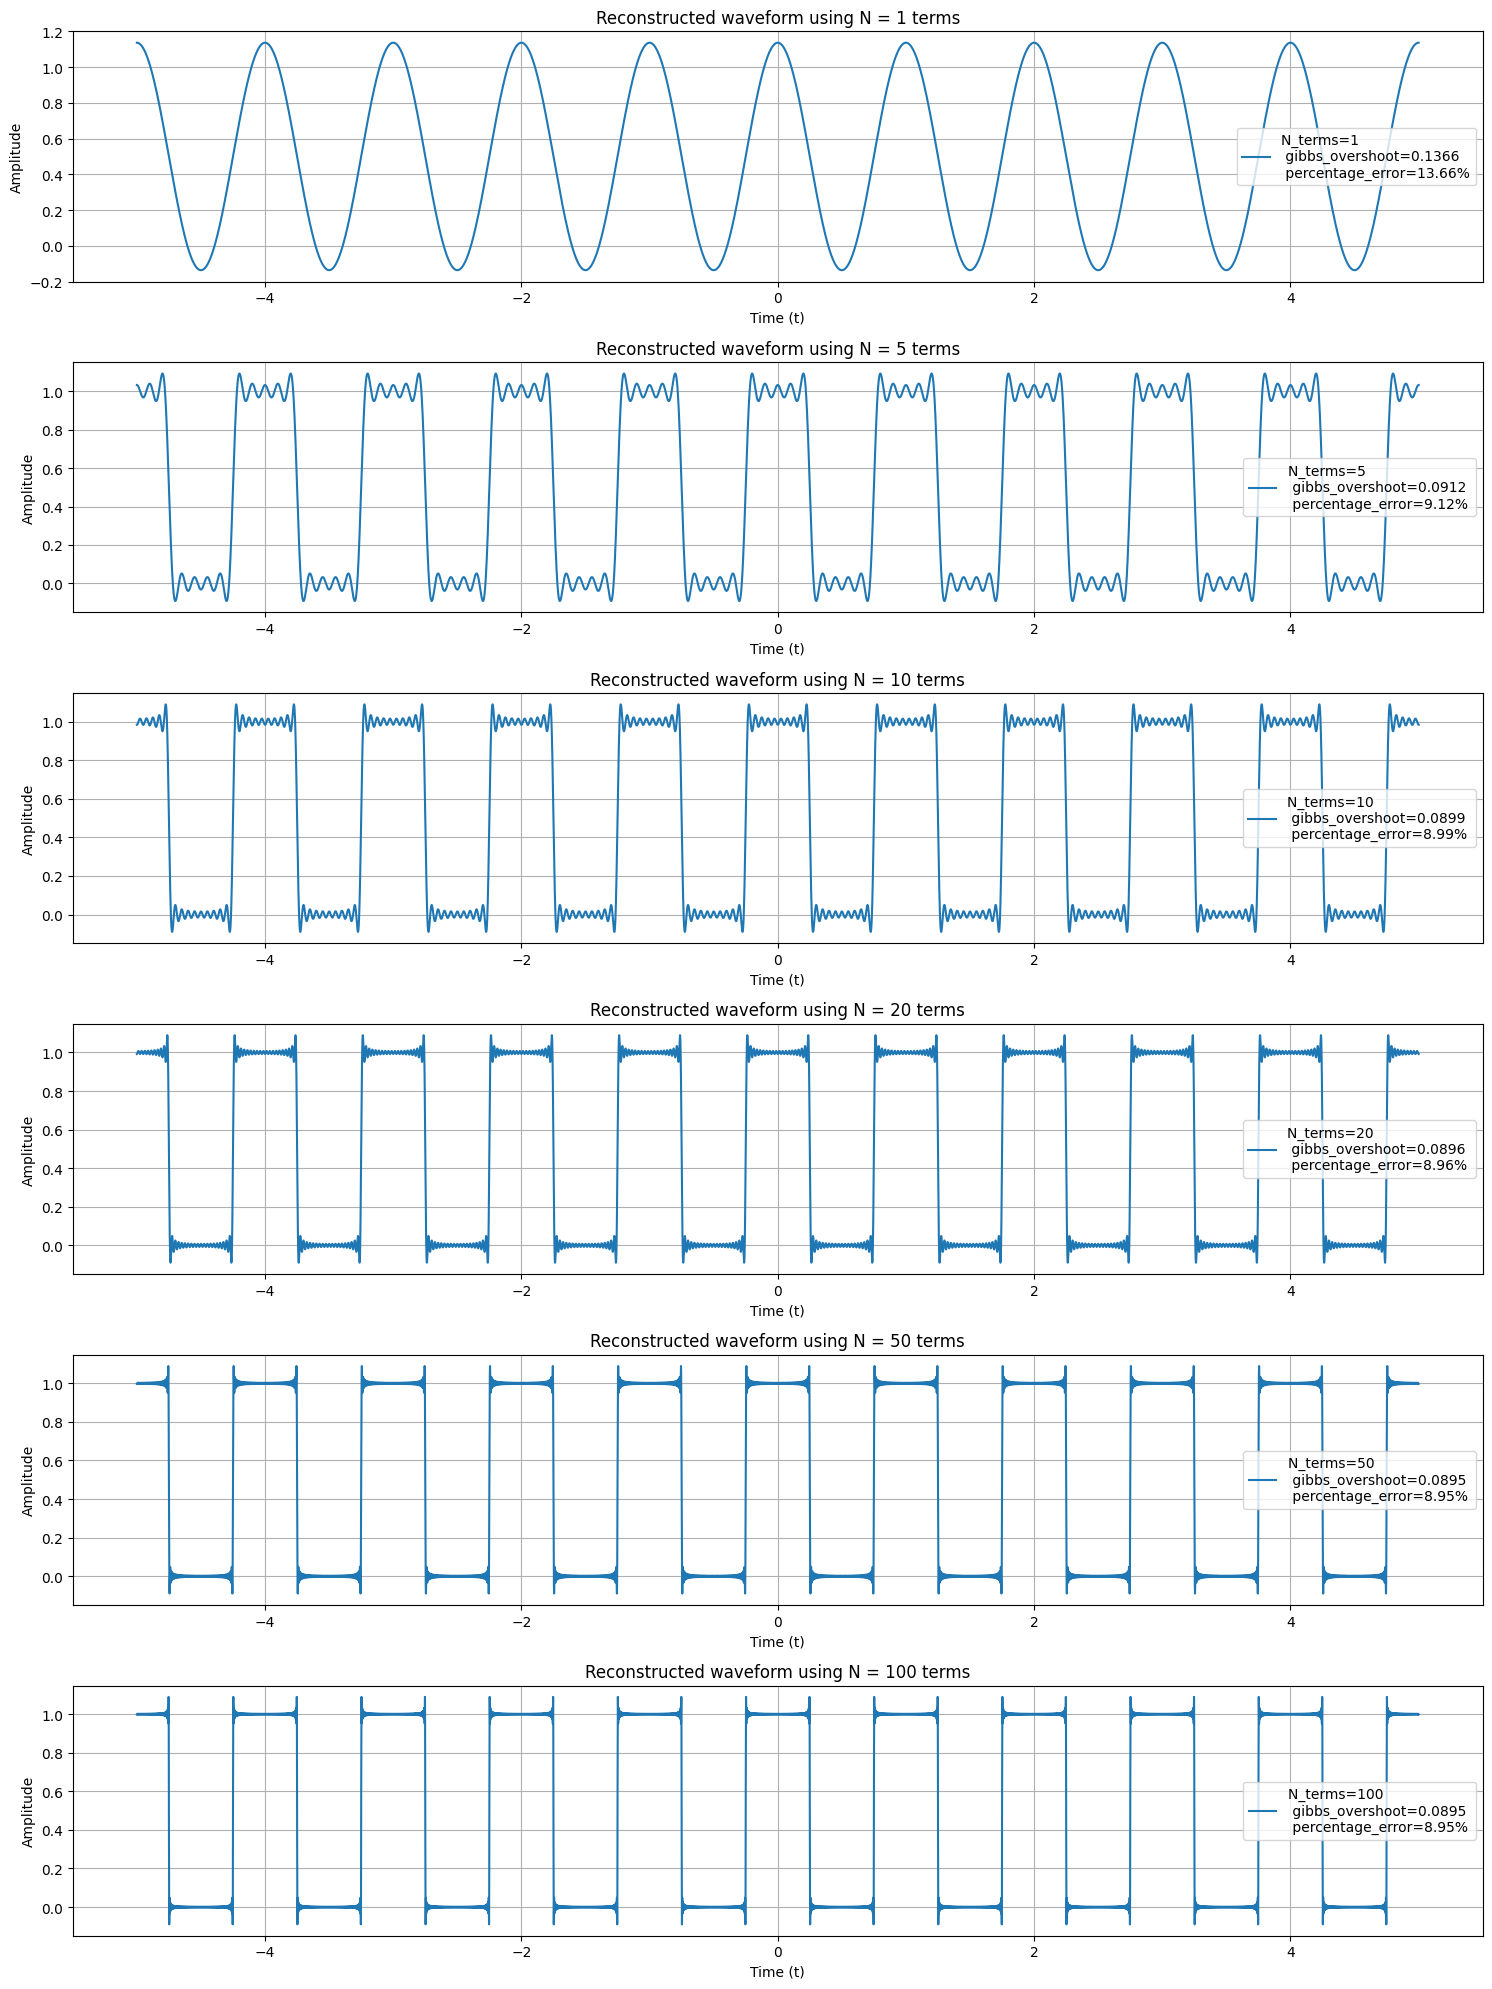

In [8]:
k_values=[1, 5, 10, 20, 50, 100]
# to get k_term/n.
ideal_amplitude = 1.0
def get_fourier_term(k_index, t_array):
  """Calculates k-th term of Fourier series n shii."""
  n_harmonic = (2 * k_index) + 1
  coefficient = ((-1)**k_index) / n_harmonic
  return coefficient * np.cos(n_harmonic * 2 * np.pi * t_array)


fig, axes = plt.subplots(len(k_values), 1, figsize=(15, 20))
for i, N_terms_to_sum in enumerate(k_values):

       # DC component (1/2)
       reconstructed_wave = np.full_like(t, 0.5)

       # Sum the Fourier series terms up to N_terms_to_sum
       #i tried integrals but it gives issues.
       for k_index in range(N_terms_to_sum):
           reconstructed_wave += (2 / np.pi) * get_fourier_term(k_index, t)

       max_amplitude_current = np.max(reconstructed_wave)

       # overshoot (absolute value)
       # Overshoot is max_amplitude - ideal_amplitude. If max_amplitude < ideal_amplitude, overshoot is 0
       gibbs_overshoot = max(0, max_amplitude_current - ideal_amplitude)

       #  percentage error
       percentage_error = (gibbs_overshoot / ideal_amplitude) * 100

       axes[i].plot(t, reconstructed_wave, label=f'N_terms={N_terms_to_sum} \n gibbs_overshoot={gibbs_overshoot:.4f} \n percentage_error={percentage_error:.2f}%')
       axes[i].set_title(f'Reconstructed waveform using N = {N_terms_to_sum} terms')
       axes[i].set_xlabel('Time (t)')
       axes[i].set_ylabel('Amplitude')
       axes[i].legend()
       axes[i].grid(True)



plt.tight_layout() # better plot layout
plt.show()